# Flipkart Customer Support Analytics

## Problem Statement
Analyzed 85,000+ real Flipkart support tickets to find out what's driving low
customer satisfaction and where the support process needs improvement.

## Tools Used
SQL, Python (pandas, Seaborn), Tableau

## Key Findings
- **Response time is the biggest driver of CSAT** — satisfaction drops steadily
  from 4.49 (replies under 5 min) to 3.77 (3+ hour replies).
- **Email is the weakest channel** (CSAT 3.91) vs calls (4.26-4.27) — likely
  because it's slower for back-and-forth.
- **Cancellation has low CSAT (3.99) despite low volume** — a bigger problem
  than its ticket count suggests, unlike Returns (high volume, still 4.35 CSAT).
- **Big gap between agents** — top performers average 4.9 CSAT, bottom performers
  as low as 1.86, pointing to a coaching opportunity.
- **Training phase (not experience) is the real weak point** — CSAT stays flat
  after training (4.27-4.36) but dips during "On Job Training" (4.14).
- **Morning shift** has the highest ticket volume but lowest CSAT (4.19) — the
  highest-impact shift to improve.

## What Needs to Improve (Business Recommendations)

1. **Speed up response times, especially on email** — response time has the
   strongest impact on CSAT, so this is the top priority.
2. **Fix the Cancellation process** — low CSAT despite low volume signals a
   frustrating experience, not just high demand.
3. **Strengthen agent onboarding/training** — CSAT dips specifically during
   "On Job Training," not after, so the training process itself needs work.
4. **Training underperforming agents** — a ~3-point CSAT gap between top and
   bottom agents suggests inconsistent skill or support, worth investigating.
5. **Add support during Morning shifts** — highest ticket volume but lowest
   CSAT makes this the highest-impact shift to staff up.

In [33]:
import pandas as pd
import sqlite3

In [2]:
df = pd.read_csv('/content/Customer_support_data.csv')

In [3]:
df.shape

(85907, 20)

In [4]:
df.head()

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [6]:
connection = sqlite3.connect('support_data.db')

In [7]:
df.to_sql('support_tickets', connection, if_exists='replace', index=False)

85907

In [8]:
check_query = "SELECT COUNT(*) AS total_rows FROM support_tickets"
pd.read_sql(check_query, connection)

,total_rows
0,85907


## Most complained categories vs CSAT
Which category gets the most tickets, and is high volume also low satisfaction?

In [10]:
query1 = """
SELECT category,
       COUNT(*) AS total_tickets,
       ROUND(AVG("CSAT Score"), 2) AS avg_csat
FROM support_tickets
GROUP BY category
ORDER BY total_tickets DESC
"""

result1 = pd.read_sql(query1, connection)
result1

,category,total_tickets,avg_csat
0,Returns,44097,4.35
1,Order Related,23215,4.10
2,Refund Related,4550,4.23
3,Product Queries,3692,4.04
4,Shopzilla Related,2792,4.31
5,Payments related,2327,4.35
6,Feedback,2294,4.16
7,Cancellation,2212,3.99
8,Offers & Cashback,480,4.21
9,Others,99,3.43


Returns get the most complaints (44,097) but still keeps a strong CSAT of 4.35 - high
volume, but not painful. Cancellation has far fewer tickets (2,212) yet the lowest
CSAT (3.99), making it a bigger concern despite lower volume.

## Response time vs CSAT
Do customers who wait longer for a response give lower satisfaction scores?





In [11]:
# Converting the timestamp columns from text into  datetime values
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d-%m-%Y %H:%M')
df['issue_responded'] = pd.to_datetime(df['issue_responded'], format='%d-%m-%Y %H:%M')

# Calculating response time in minutes
df['response_time_minutes'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

df[['Issue_reported at', 'issue_responded', 'response_time_minutes']].head() # For looking a new column

,Issue_reported at,issue_responded,response_time_minutes
0,2023-08-01 11:13:00,2023-08-01 11:47:00,34.0
1,2023-08-01 12:52:00,2023-08-01 12:54:00,2.0
2,2023-08-01 20:16:00,2023-08-01 20:38:00,22.0
3,2023-08-01 20:56:00,2023-08-01 21:16:00,20.0
4,2023-08-01 10:30:00,2023-08-01 10:32:00,2.0


In [12]:
# Checking overall statistics of response time to spot any weird values
df['response_time_minutes'].describe()

,response_time_minutes
count,85907.000000
mean,136.886610
std,592.528551
min,-1437.000000
25%,2.000000
50%,5.000000
75%,35.000000
max,5758.000000


In [13]:
# Removing negative values as response time cannot be negative
df_clean = df[df['response_time_minutes'] >= 0]

# Checking how many rows we removed
print("Original rows:", len(df))
print("Rows after removing negative response times:", len(df_clean))

Original rows: 85907
Rows after removing negative response times: 82779


In [14]:
df_clean['response_time_minutes'].describe() # Now the negative value is removed

,response_time_minutes
count,82779.000000
mean,176.063965
std,565.196490
min,0.000000
25%,2.000000
50%,6.000000
75%,39.000000
max,5758.000000


A few tickets took unusually long (up to 5758 minutes), which would skew the analysis.
I capped the data at the 99th percentile to focus on typical cases.

In [15]:
cutoff = df_clean['response_time_minutes'].quantile(0.99)
cutoff

np.float64(3047.220000000001)

In [16]:
# Keeping only tickets within the 99th percentile (removing extreme outliers)
df_final = df_clean[df_clean['response_time_minutes'] <= cutoff]

# Checking how many rows we kept
len(df_final)

81951

In [19]:
# Group response times into categories (fast, medium, slow)
df_final['response_bucket'] = pd.cut(
df_final['response_time_minutes'],
    bins=[0, 5, 15, 30, 60, 180, 3050],
    labels=['0-5 min', '5-15 min', '15-30 min', '30-60 min', '1-3 hrs', '3+ hrs']
)

# Check average CSAT score for each group
df_final.groupby('response_bucket')['CSAT Score'].mean().round(2)

/tmp/ipykernel_592/3092307998.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['response_bucket'] = pd.cut(
/tmp/ipykernel_592/3092307998.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby('response_bucket')['CSAT Score'].mean().round(2)


,CSAT Score
response_bucket,
0-5 min,4.49
5-15 min,4.26
15-30 min,4.02
30-60 min,3.96
1-3 hrs,3.95
3+ hrs,3.77


CSAT drops steadily as response time increases from 4.49 for replies under 5 minutes, down to 3.77 for replies taking 3+ hours. Faster responses clearly mean happier customers.

## Visualizing response time vs CSAT


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_592/151572766.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chart_data = df_final.groupby('response_bucket')['CSAT Score'].mean().round(2)


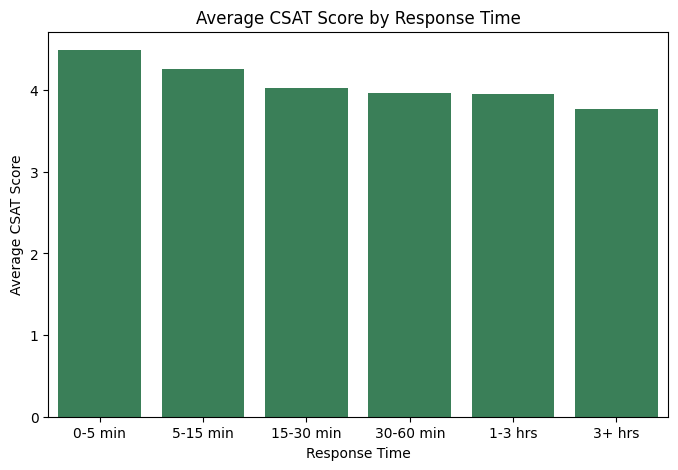

In [22]:
# Calculating average CSAT per response time bucket
chart_data = df_final.groupby('response_bucket')['CSAT Score'].mean().round(2)

plt.figure(figsize=(8,5))
sns.barplot(x=chart_data.index, y=chart_data.values, color='seagreen')
plt.title('Average CSAT Score by Response Time')
plt.xlabel('Response Time')
plt.ylabel('Average CSAT Score')
plt.show()

## Channel performance
Which support channel (call, email, etc.) has the best and worst CSAT?

In [23]:
# We're checking average CSAT and ticket volume for each channel
df_final.groupby('channel_name')['CSAT Score'].agg(['count', 'mean']).round(2)

,count,mean
channel_name,,
Email,2861,3.91
Inbound,65107,4.26
Outcall,13983,4.27



Email has the lowest CSAT (3.91) and lowest volume, while Inbound and Outcall calls
perform almost the same (4.26-4.27). This lines up with the response time finding,
calls resolve issues faster and in real time, while email tends to be slower.

## Visualizing channel performance

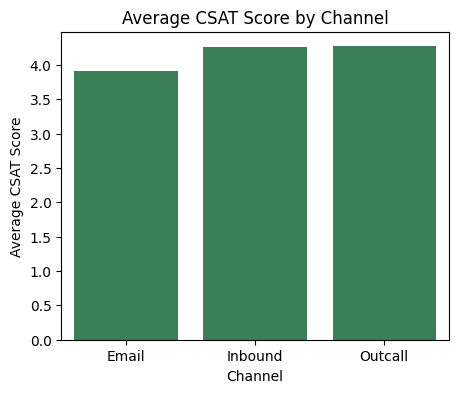

In [25]:
# Average CSAT per channel
channel_data = df_final.groupby('channel_name')['CSAT Score'].mean().round(2)


plt.figure(figsize=(5,4))
sns.barplot(x=channel_data.index, y=channel_data.values, color='seagreen')
plt.title('Average CSAT Score by Channel')
plt.xlabel('Channel')
plt.ylabel('Average CSAT Score')
plt.show()

## Agent performance
Which agents have the best CSAT, and how many tickets do they handle?

In [26]:
# Checking ticket count and average CSAT for each agent
agent_performance = df_final.groupby('Agent_name')['CSAT Score'].agg(['count', 'mean']).round(2)

# Sorting by average CSAT, highest first
agent_performance = agent_performance.sort_values('mean', ascending=False)

# Top 10 agents
agent_performance.head(10)

,count,mean
Agent_name,,
Pamela Robinson,22,4.95
Sean Gay,22,4.91
Virginia Lane,106,4.91
Taylor Nelson,41,4.88
Alan Cruz,43,4.88
John Hoffman,34,4.88
Kelsey Richardson,49,4.88
Morgan Smith,45,4.87
Nancy Singh,38,4.87


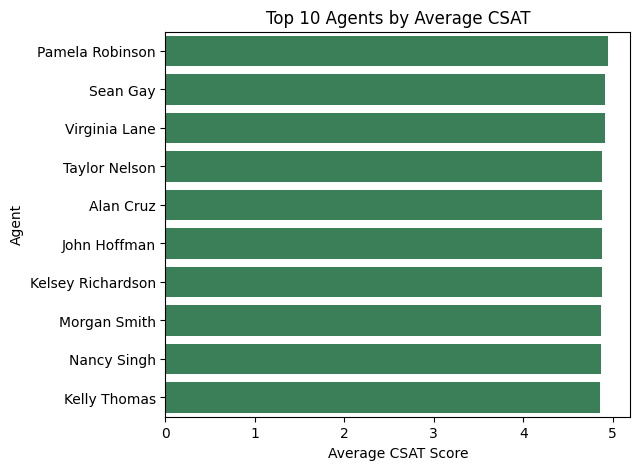

In [31]:
plt.figure(figsize=(6,5))
sns.barplot(x=agent_performance.head(10)['mean'], y=agent_performance.head(10).index, color='seagreen')
plt.title('Top 10 Agents by Average CSAT')
plt.xlabel('Average CSAT Score')
plt.ylabel('Agent')
plt.show()

In [27]:
# Bottom 10 agents by average CSAT (but only agents with a reasonable number of tickets)
agent_performance_filtered = agent_performance[agent_performance['count'] >= 10]
agent_performance_filtered.sort_values('mean').head(10)

,count,mean
Agent_name,,
Rebecca Miller,21,1.86
Philip Harmon,19,1.89
Curtis Mccarthy,30,2.10
Virginia Mccormick,31,2.13
Charles Morales,33,2.18
Wesley Meyer,27,2.26
Nicole Zavala,26,2.31
Tommy Davies,35,2.34
Pamela Perez,34,2.38



There's a big gap between top and bottom agents - top performers average around
4.9 CSAT, while the lowest average as low as 1.86-2.4, both with enough tickets
to be reliable (not just bad luck). This points to a real training
opportunity rather than random variation.

## Does agent experience affect CSAT?
Do newer agents have lower satisfaction scores than experienced ones?

In [29]:
df_final.groupby('Tenure Bucket')['CSAT Score'].agg(['count', 'mean']).round(2)

,count,mean
Tenure Bucket,,
0-30,10850,4.27
31-60,11316,4.30
61-90,6507,4.36
>90,29450,4.28
On Job Training,23828,4.14


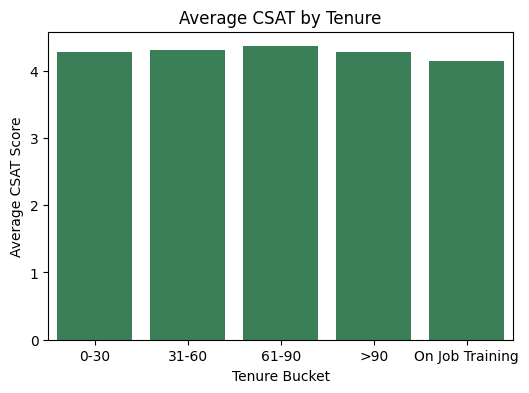

In [32]:
tenure_data = df_final.groupby('Tenure Bucket')['CSAT Score'].mean().round(2)

plt.figure(figsize=(6,4))
sns.barplot(x=tenure_data.index, y=tenure_data.values, color='seagreen')
plt.title('Average CSAT by Tenure')
plt.xlabel('Tenure Bucket')
plt.ylabel('Average CSAT Score')
plt.show()

Experience barely matters once agents are trained - CSAT stays around 4.27-4.36
from 0-30 days all the way to 90+ days. The real dip is during "On Job Training"
(4.14), suggesting the training phase itself, not overall experience, is where
support quality drops.

## Does shift affect CSAT?
Does ticket volume or satisfaction change depending on the agent's shift?



In [30]:
df_final.groupby('Agent Shift')['CSAT Score'].agg(['count', 'mean']).round(2)

,count,mean
Agent Shift,,
Afternoon,5601,4.30
Evening,32139,4.28
Morning,39396,4.19
Night,1272,4.31
Split,3543,4.44


Morning has the lowest CSAT (4.19) despite handling the most tickets (39,396) -
making it the highest-impact shift to improve. Split shift has the best CSAT (4.44)
but very low volume.